# Delta CISI Projections

Projects future CISI by anchoring to the observed 2024 CISI baseline.

**Method:**
1. Run model on 2024 inputs → baseline prediction
2. Run model on each SSP scenario → future prediction
3. Compute delta = future − baseline per pixel
4. Apply delta to actual 2024 CISI: `projected = actual_CISI_2024 + delta`

This cancels the model's absolute underprediction bias and uses it purely as a change detector.

## 1. Imports and setup

In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import rasterio
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
import sys as _sys; _sys.path.insert(0, __import__('os').path.abspath('.'))
from src.fill import fill_input_stack

Device: cpu


## 2. Model definition

In [2]:
# Model class not needed — predictions loaded from projections_output/

## 3. Paths

In [3]:
CISI_PATH   = r'READY_data\labels\2024_CISI_010deg_nearest.tif'
SHP_PATH    = r'ne_10m_admin_0_countries\ne_10m_admin_0_countries.shp'
PRED_DIR    = 'projections_output'   # TIFs written by projections.ipynb
OUTPUT_DIR  = 'projections_output'   # delta TIFs written here
NORM_DIR    = r'READY_data\inputs_normalized\ssp'

os.makedirs(OUTPUT_DIR, exist_ok=True)

SSPS  = ['SSP1', 'SSP2', 'SSP3', 'SSP4', 'SSP5']
YEARS = [2030, 2050, 2100]

## 4. Load model and reference data

In [ ]:
with rasterio.open(CISI_PATH) as src:
    cisi_2024   = src.read(1).astype(np.float32)
    REF_SHAPE   = (src.height, src.width)
    REF_BOUNDS  = src.bounds
    REF_PROFILE = src.profile.copy()

cisi_mask_px = int((~np.isnan(cisi_2024)).sum())
print(f'~isnan(cisi_2024) pixels : {cisi_mask_px:,}')

# Same EU27 shapefile-rasterised mask that projections.ipynb saves
MASK_PATH  = r'READY_data\labels\eu_mask_010deg.tif'
with rasterio.open(MASK_PATH) as src:
    VALID_MASK = src.read(1).astype(bool)
print(f'EU27 shapefile mask      : {VALID_MASK.sum():,} pixels')
print(f'Difference               : {int(VALID_MASK.sum()) - cisi_mask_px:+,} pixels')

# Load all 15 prediction TIFs produced by projections.ipynb
predictions = {}
for ssp in SSPS:
    predictions[ssp] = {}
    for year in YEARS:
        path = f'{PRED_DIR}/cisi_pred_{ssp}_{year}.tif'
        with rasterio.open(path) as src:
            predictions[ssp][year] = src.read(1).astype(np.float32)
        print(f'  Loaded {ssp}-{year}: mean={np.nanmean(predictions[ssp][year]):.4f}')

# Baseline = historic CISI
with rasterio.open(r'READY_data\labels\CISI_010deg.tif') as src:
    baseline = src.read(1).astype(np.float32)
baseline[~VALID_MASK] = np.nan
print(f'
Baseline (historic CISI): mean={np.nanmean(baseline):.4f}  max={np.nanmax(baseline):.4f}')

# Save baseline TIF
profile = REF_PROFILE.copy(); profile.update(dtype='float32', count=1, nodata=np.nan)
with rasterio.open(f'{OUTPUT_DIR}/baseline_historic_cisi.tif', 'w', **profile) as dst:
    dst.write(baseline[np.newaxis])
print('Saved baseline_historic_cisi.tif')


## 5. Helper functions

In [5]:
def build_stack(gdp_path, pop_path, lc_paths):
    with rasterio.open(gdp_path) as src: gdp = src.read(1).astype(np.float32)
    with rasterio.open(pop_path) as src: pop = src.read(1).astype(np.float32)
    lc = np.concatenate([rasterio.open(p).read().astype(np.float32) for p in lc_paths], axis=0)
    stack = np.concatenate([gdp[np.newaxis], pop[np.newaxis], lc], axis=0)
    return fill_input_stack(stack)

## 6. Compute baseline prediction (2024 inputs)

In [ ]:
# Baseline = historic CISI (computed in dp08)
# Source file: projections_output/baseline_historic_cisi.tif
b_vals = baseline[VALID_MASK]
print(f'Baseline (historic CISI):  mean={b_vals.mean():.4f}  median={np.median(b_vals):.4f}  max={b_vals.max():.4f}')
print(f'Valid pixels: {VALID_MASK.sum():,}')


## 7. Run delta projections for all SSP scenarios

In [7]:
results_delta = {}

profile = REF_PROFILE.copy(); profile.update(dtype='float32', count=1, nodata=np.nan)

for ssp in SSPS:
    results_delta[ssp] = {}
    for year in YEARS:
        pred_future = predictions[ssp][year].copy()
        pred_future[~VALID_MASK] = np.nan
        delta = pred_future - baseline
        delta[~VALID_MASK] = np.nan

        results_delta[ssp][year] = delta

        with rasterio.open(f'{OUTPUT_DIR}/delta_{ssp}_{year}.tif', 'w', **profile) as dst:
            dst.write(delta[np.newaxis])

        print(f'{ssp} {year}: delta mean={np.nanmean(delta):+.4f}  min={np.nanmin(delta):.4f}  max={np.nanmax(delta):.4f}  pred mean={np.nanmean(pred_future):.4f}  pred max={np.nanmax(pred_future):.4f}')

print('Done.')

SSP1 2030: delta mean=+0.0000  min=-0.0757  max=0.0690  pred mean=0.0955  pred max=0.4954
SSP1 2050: delta mean=+0.0019  min=-0.1052  max=0.1371  pred mean=0.0975  pred max=0.4814
SSP1 2100: delta mean=+0.0024  min=-0.1412  max=0.1503  pred mean=0.0979  pred max=0.4574
SSP2 2030: delta mean=+0.0002  min=-0.0432  max=0.0512  pred mean=0.0957  pred max=0.4864
SSP2 2050: delta mean=+0.0018  min=-0.0901  max=0.1023  pred mean=0.0973  pred max=0.4733


SSP2 2100: delta mean=+0.0028  min=-0.1505  max=0.1445  pred mean=0.0983  pred max=0.4522
SSP3 2030: delta mean=-0.0007  min=-0.0579  max=0.0505  pred mean=0.0948  pred max=0.4909
SSP3 2050: delta mean=-0.0004  min=-0.1131  max=0.0924  pred mean=0.0952  pred max=0.4887
SSP3 2100: delta mean=-0.0018  min=-0.1570  max=0.1164  pred mean=0.0937  pred max=0.5055
SSP4 2030: delta mean=+0.0001  min=-0.0391  max=0.0638  pred mean=0.0957  pred max=0.4982
SSP4 2050: delta mean=+0.0013  min=-0.1075  max=0.1204  pred mean=0.0968  pred max=0.4827
SSP4 2100: delta mean=-0.0001  min=-0.1511  max=0.1641  pred mean=0.0954  pred max=0.4360


SSP5 2030: delta mean=+0.0004  min=-0.0471  max=0.0453  pred mean=0.0959  pred max=0.4958


SSP5 2050: delta mean=+0.0039  min=-0.1192  max=0.1047  pred mean=0.0994  pred max=0.4806
SSP5 2100: delta mean=+0.0058  min=-0.1572  max=0.1745  pred mean=0.1013  pred max=0.4830
Done.


## 8. Maps — projected CISI per year (all SSPs)

Saved figures/projections_2030.png


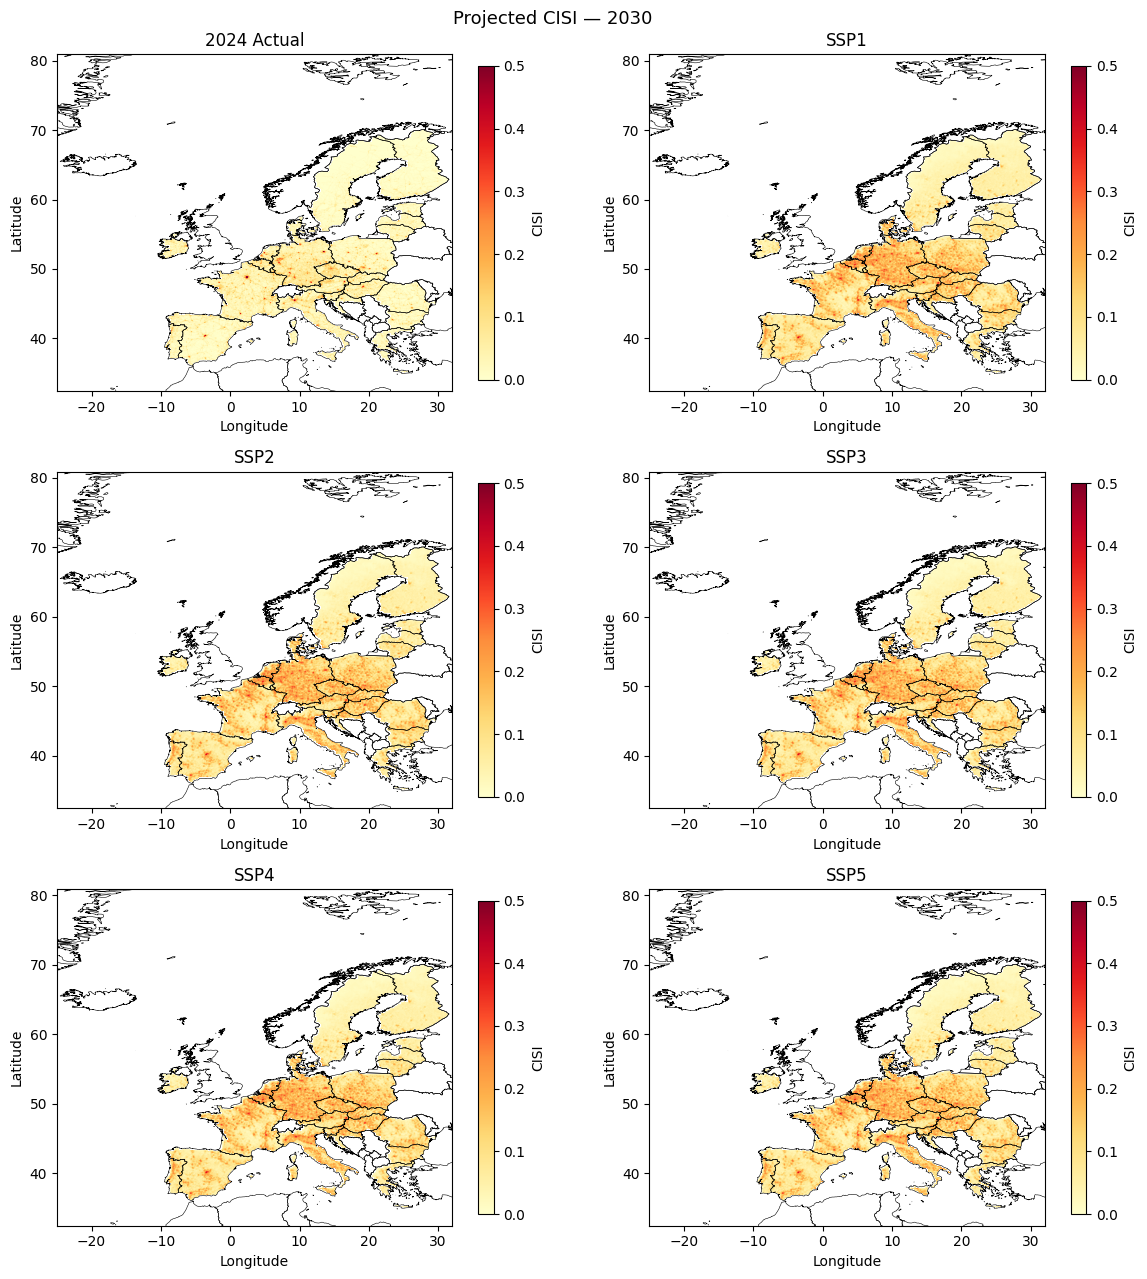

Saved figures/projections_2050.png


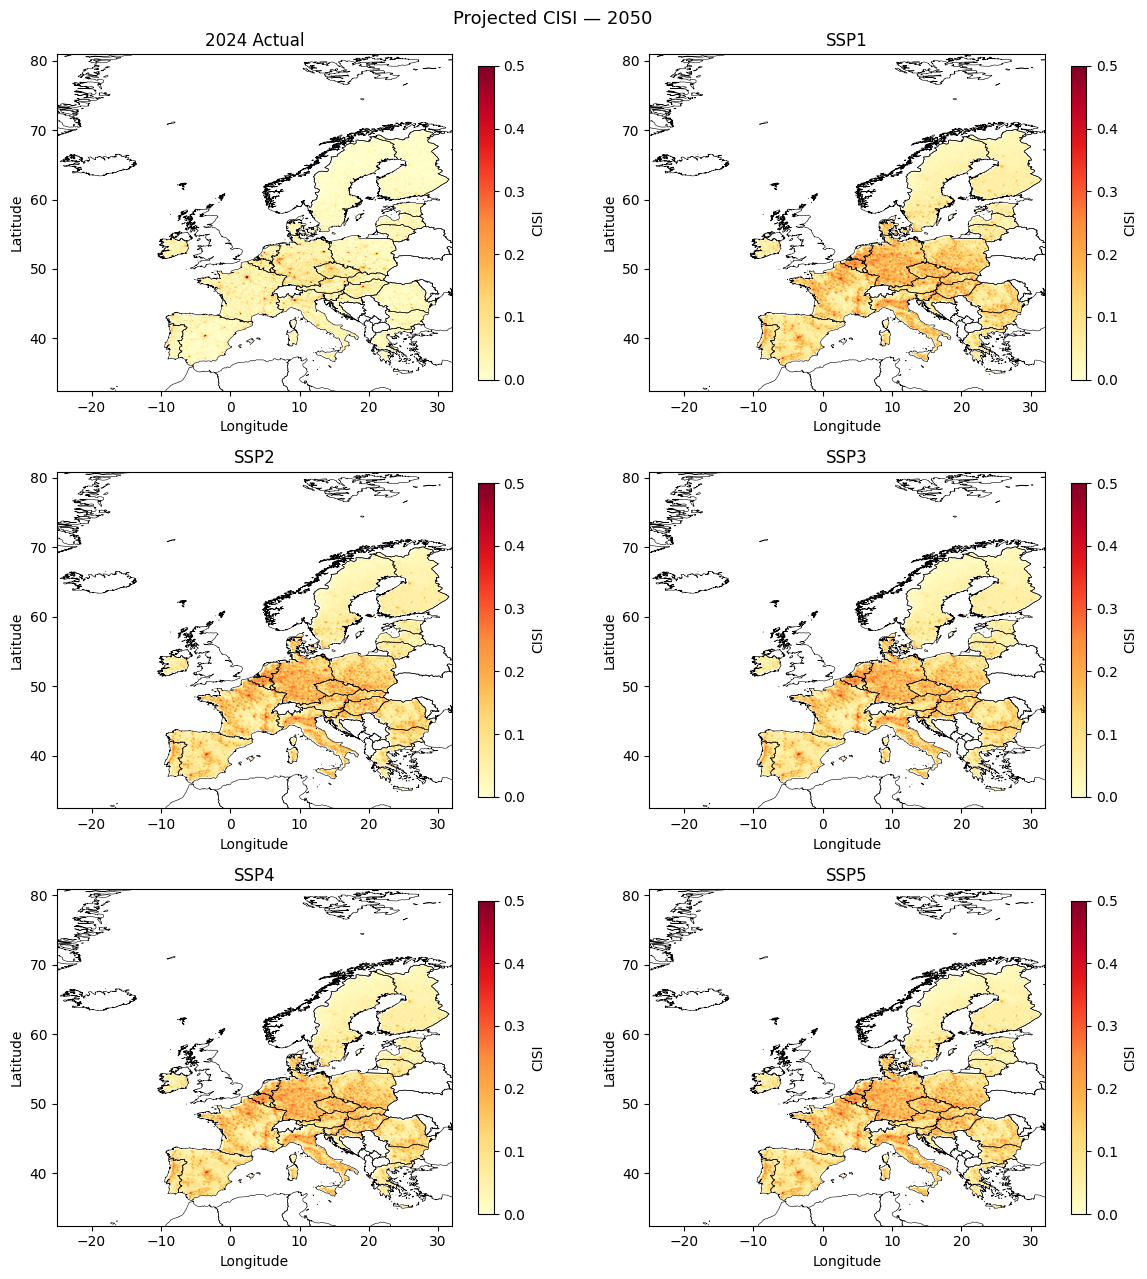

Saved figures/projections_2100.png


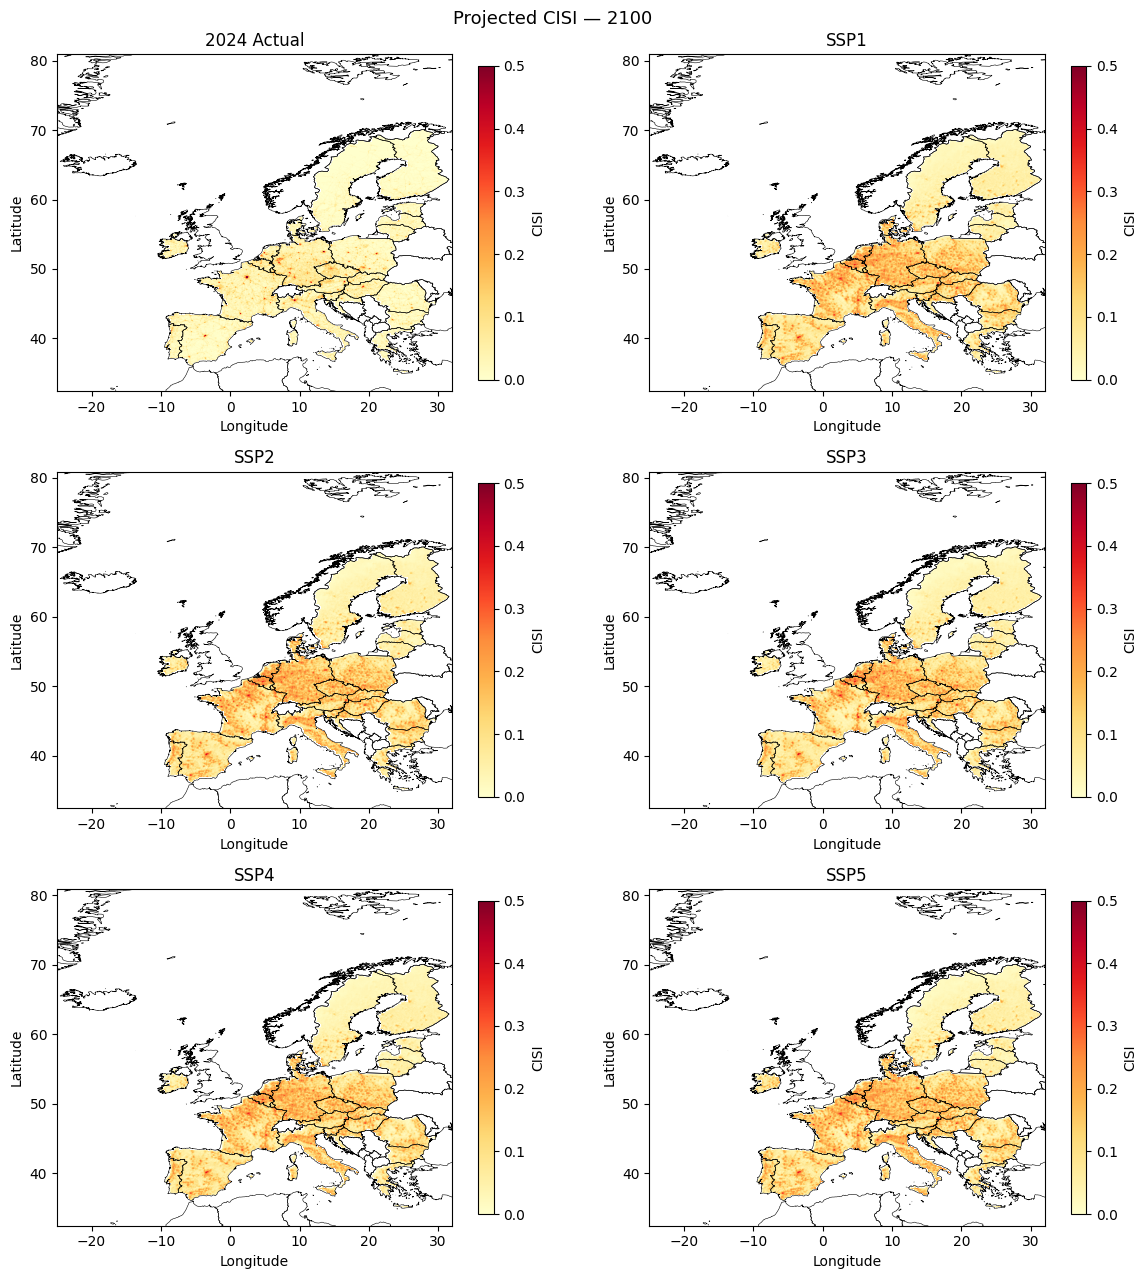

In [8]:
world = gpd.read_file(SHP_PATH)
ext   = [REF_BOUNDS.left, REF_BOUNDS.right, REF_BOUNDS.bottom, REF_BOUNDS.top]

for year in YEARS:
    panels = [
        ("2024 Actual", cisi_2024),
        ("SSP1", predictions["SSP1"][year]),
        ("SSP2", predictions["SSP2"][year]),
        ("SSP3", predictions["SSP3"][year]),
        ("SSP4", predictions["SSP4"][year]),
        ("SSP5", predictions["SSP5"][year]),
    ]

    fig, axes = plt.subplots(3, 2, figsize=(12, 13))
    fig.suptitle(f"Projected CISI — {year}", fontsize=13)

    for ax, (title, data) in zip(axes.flat, panels):
        d = data.copy(); d[~VALID_MASK] = np.nan
        im = ax.imshow(d, cmap="YlOrRd", vmin=0, vmax=0.5,
                       extent=ext, origin="upper", aspect="auto")
        world.boundary.plot(ax=ax, linewidth=0.4, color="black")
        ax.set_xlim(REF_BOUNDS.left, REF_BOUNDS.right)
        ax.set_ylim(REF_BOUNDS.bottom, REF_BOUNDS.top)
        ax.set_title(title)
        ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
        plt.colorbar(im, ax=ax, label="CISI", fraction=0.03)

    plt.tight_layout()
    out_fig = f"figures/projections_{year}.png"
    plt.savefig(out_fig, dpi=150, bbox_inches='tight')
    print(f"Saved {out_fig}")
    plt.show()


## 9. Delta maps — change relative to 2024 baseline

Saved figures/delta_change_2030.png


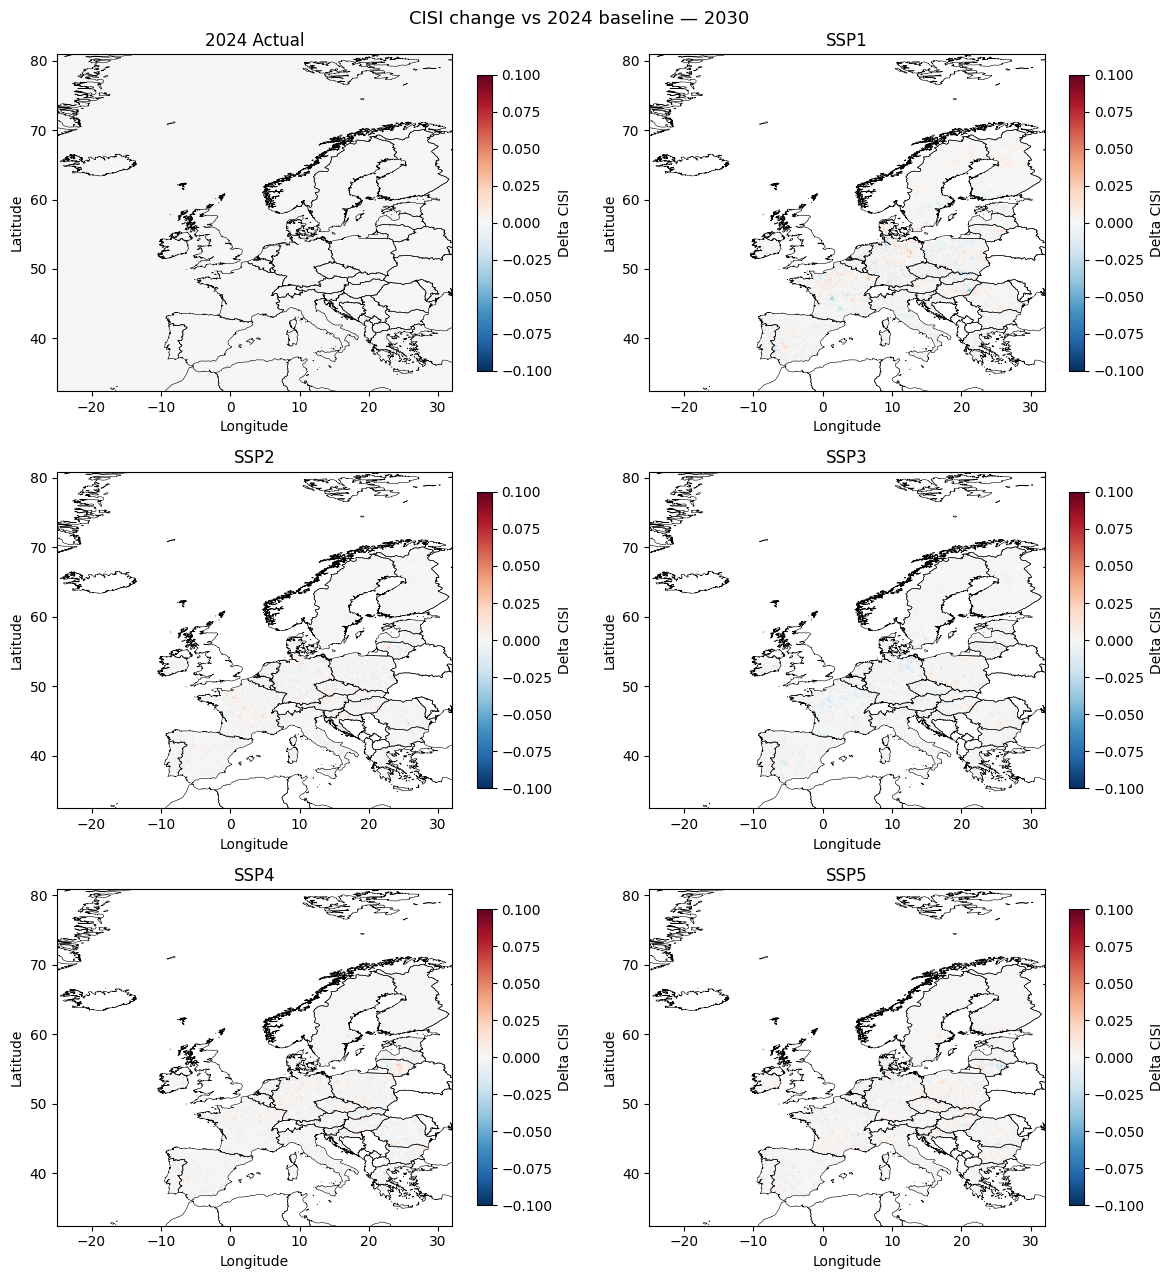

Saved figures/delta_change_2050.png


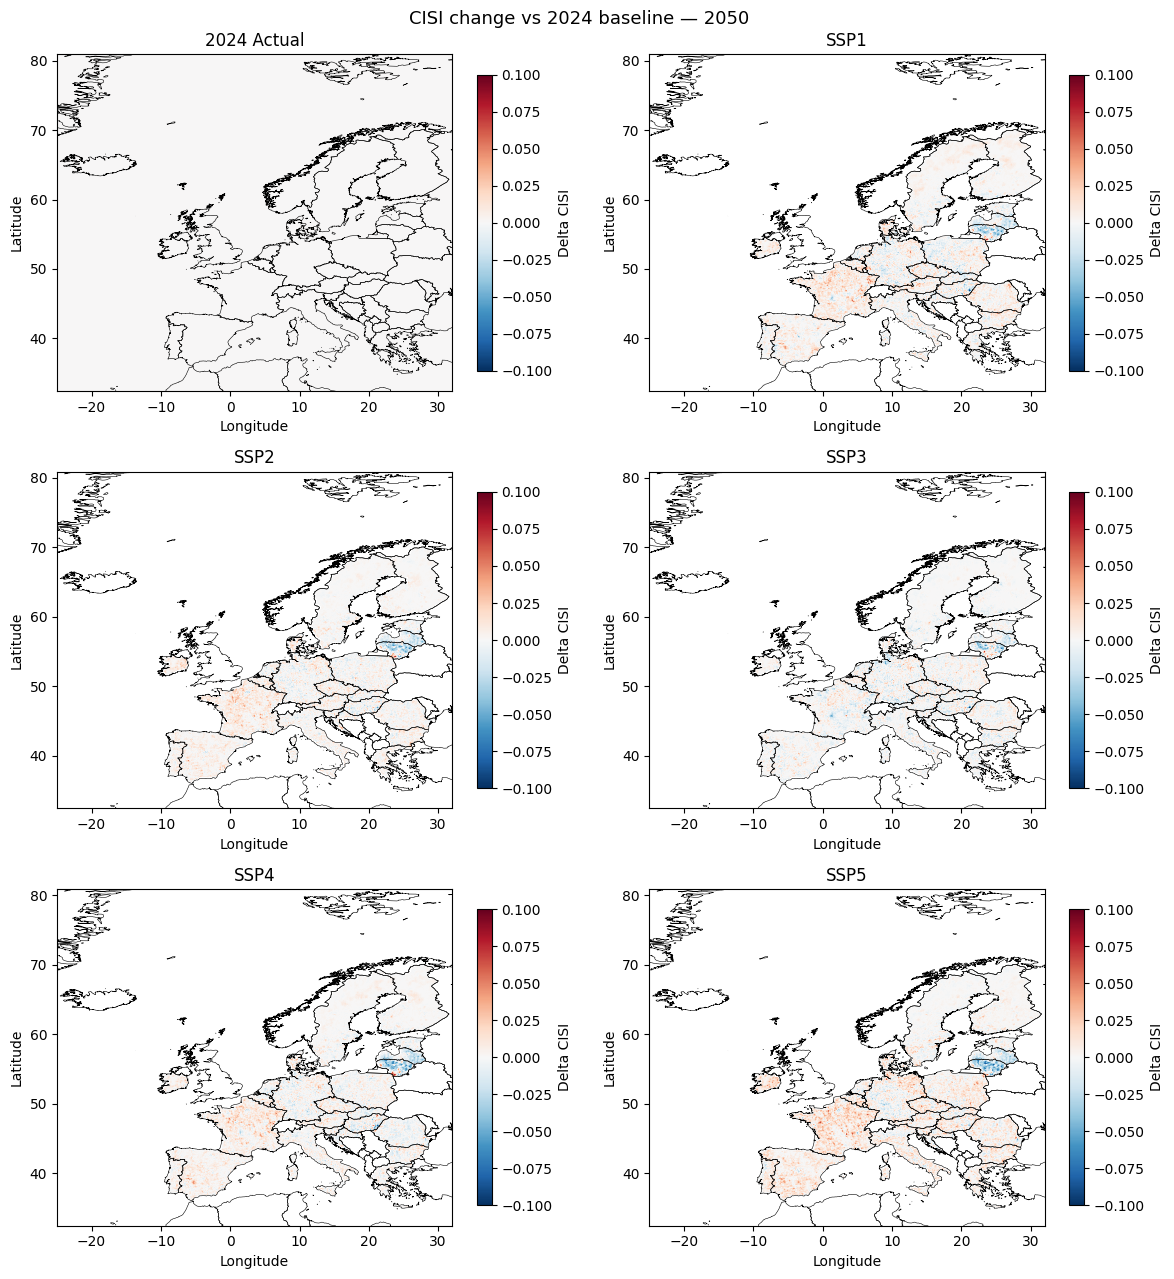

Saved figures/delta_change_2100.png


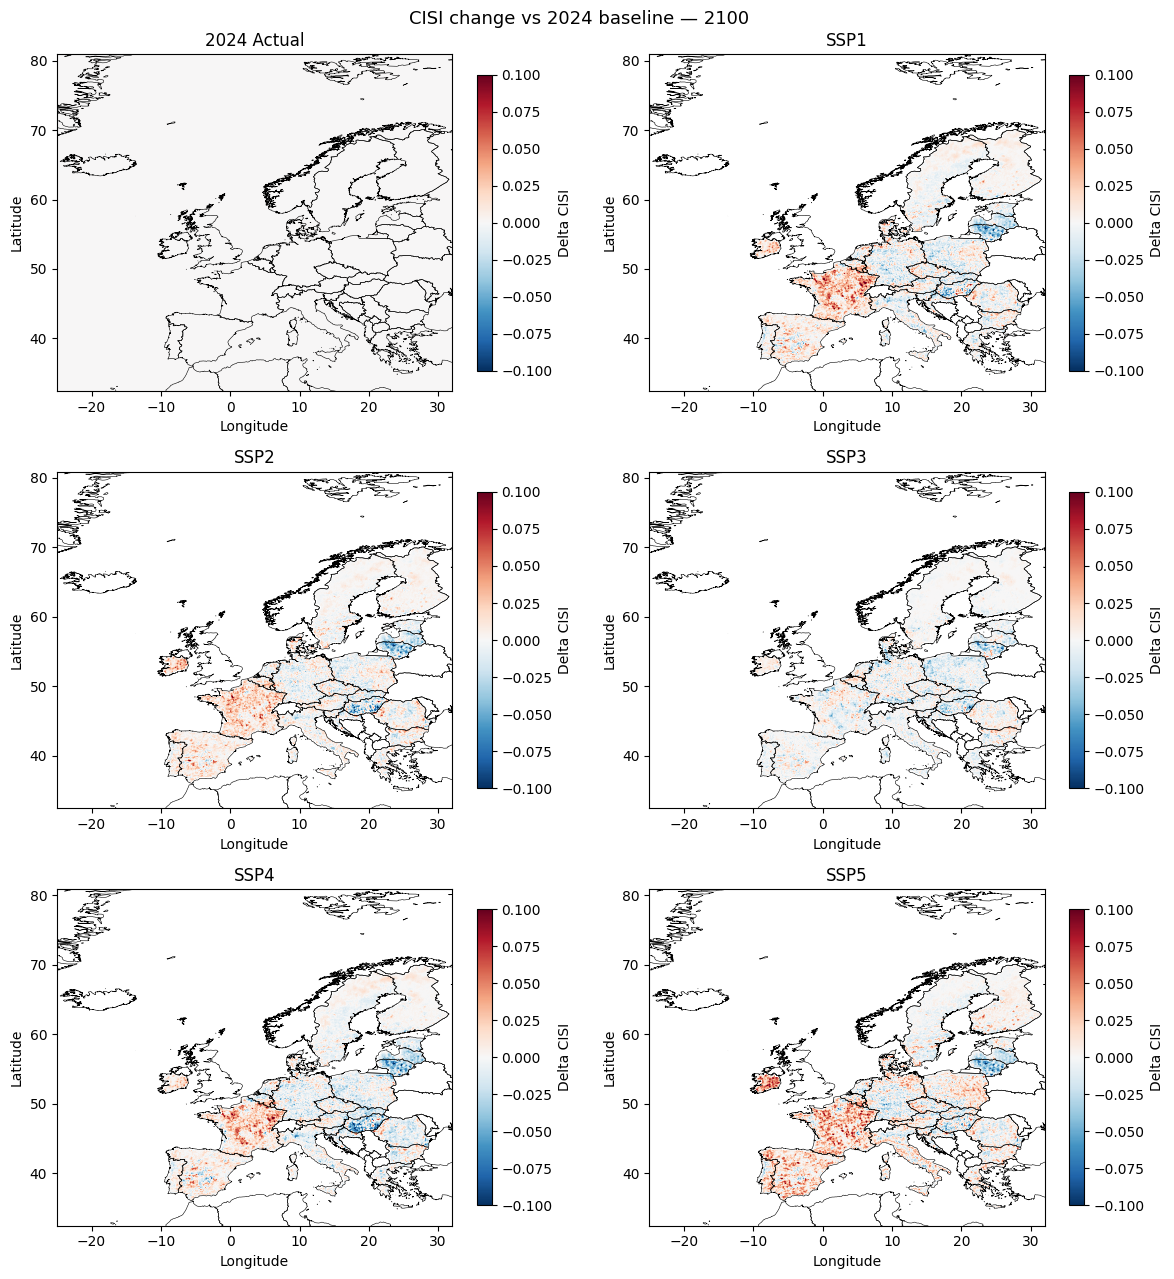

In [9]:
for year in YEARS:
    panels = [
        ("2024 Actual", np.zeros_like(cisi_2024)),  # 0 delta for baseline
        ("SSP1", results_delta["SSP1"][year]),
        ("SSP2", results_delta["SSP2"][year]),
        ("SSP3", results_delta["SSP3"][year]),
        ("SSP4", results_delta["SSP4"][year]),
        ("SSP5", results_delta["SSP5"][year]),
    ]

    fig, axes = plt.subplots(3, 2, figsize=(12, 13))
    fig.suptitle(f"CISI change vs 2024 baseline — {year}", fontsize=13)

    for ax, (title, data) in zip(axes.flat, panels):
        im = ax.imshow(data, cmap="RdBu_r", vmin=-0.1, vmax=0.1,
                       extent=ext, origin="upper", aspect="auto")
        world.boundary.plot(ax=ax, linewidth=0.4, color="black")
        ax.set_xlim(REF_BOUNDS.left, REF_BOUNDS.right)
        ax.set_ylim(REF_BOUNDS.bottom, REF_BOUNDS.top)
        ax.set_title(title)
        ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
        plt.colorbar(im, ax=ax, label="Delta CISI", fraction=0.03)

    plt.tight_layout()
    out_fig = f"figures/delta_change_{year}.png"
    plt.savefig(out_fig, dpi=150, bbox_inches="tight")
    print(f"Saved {out_fig}")
    plt.show()


## 10. Summary statistics

In [10]:
print(f"{'SSP':<6} {'Year':>6} {'Mean pred':>12} {'Mean delta':>12} {'Max pred':>10} {'High>0.15 (%)':>14}")
print("-" * 60)
for ssp in SSPS:
    for year in YEARS:
        pred_future = predictions[ssp][year].copy()
        pred_future[~VALID_MASK] = np.nan
        delta = results_delta[ssp][year]
        valid = pred_future[~np.isnan(pred_future)]
        high  = (valid > 0.15).mean() * 100
        print(f"{ssp:<6} {year:>6} {valid.mean():>12.4f} {np.nanmean(delta):>+12.4f} {valid.max():>10.4f} {high:>13.1f}%")


SSP      Year    Mean pred   Mean delta   Max pred  High>0.15 (%)
------------------------------------------------------------
SSP1     2030       0.0955      +0.0000     0.4954          21.3%
SSP1     2050       0.0975      +0.0019     0.4814          22.8%
SSP1     2100       0.0979      +0.0024     0.4574          23.4%
SSP2     2030       0.0957      +0.0002     0.4864          21.4%
SSP2     2050       0.0973      +0.0018     0.4733          22.7%
SSP2     2100       0.0983      +0.0028     0.4522          23.5%
SSP3     2030       0.0948      -0.0007     0.4909          20.9%
SSP3     2050       0.0952      -0.0004     0.4887          21.6%
SSP3     2100       0.0937      -0.0018     0.5055          20.7%
SSP4     2030       0.0957      +0.0001     0.4982          21.5%
SSP4     2050       0.0968      +0.0013     0.4827          22.6%
SSP4     2100       0.0954      -0.0001     0.4360          22.1%
SSP5     2030       0.0959      +0.0004     0.4958          21.7%
SSP5     2050  

## 11. Summary statistics plots — all years

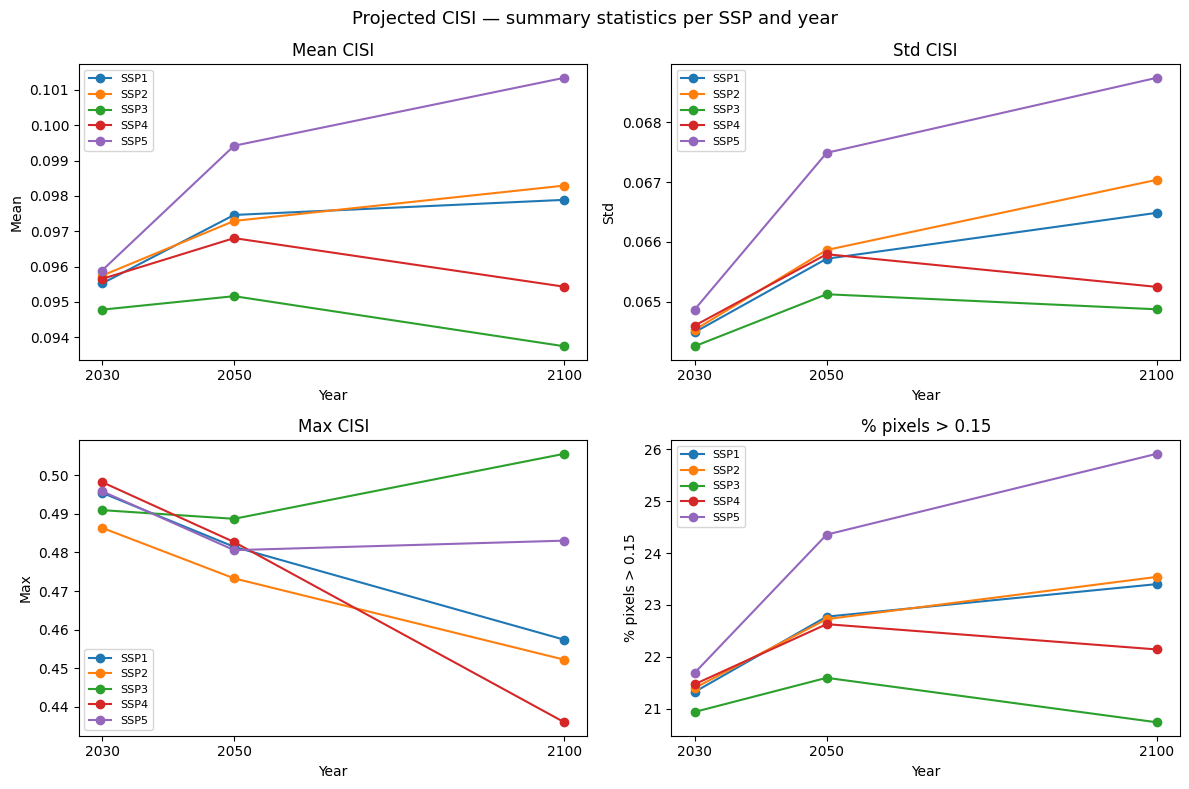

In [11]:
YEARS_ALL = [2030, 2050, 2100]

stats_proj = {ssp: {"mean": [], "std": [], "max": [], "high": []} for ssp in SSPS}
for ssp in SSPS:
    for year in YEARS_ALL:
        pred_future = predictions[ssp][year].copy()
        pred_future[~VALID_MASK] = np.nan
        valid = pred_future[~np.isnan(pred_future)]
        stats_proj[ssp]["mean"].append(valid.mean())
        stats_proj[ssp]["std"].append(valid.std())
        stats_proj[ssp]["max"].append(valid.max())
        stats_proj[ssp]["high"].append((valid > 0.15).mean() * 100)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Projected CISI — summary statistics per SSP and year", fontsize=13)

keys    = ["mean", "std", "max", "high"]
titles  = ["Mean CISI", "Std CISI", "Max CISI", "% pixels > 0.15"]
ylabels = ["Mean", "Std", "Max", "% pixels > 0.15"]

for ax, key, title, ylabel in zip(axes.flat, keys, titles, ylabels):
    for ssp in SSPS:
        ax.plot(YEARS_ALL, stats_proj[ssp][key], marker="o", label=ssp)
    ax.set_title(title)
    ax.set_xlabel("Year")
    ax.set_ylabel(ylabel)
    ax.set_xticks(YEARS_ALL)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('figures/summary_stats.png', dpi=150, bbox_inches='tight')
plt.show()


## 12. 2024 vs 2030 — observed baseline on x-axis

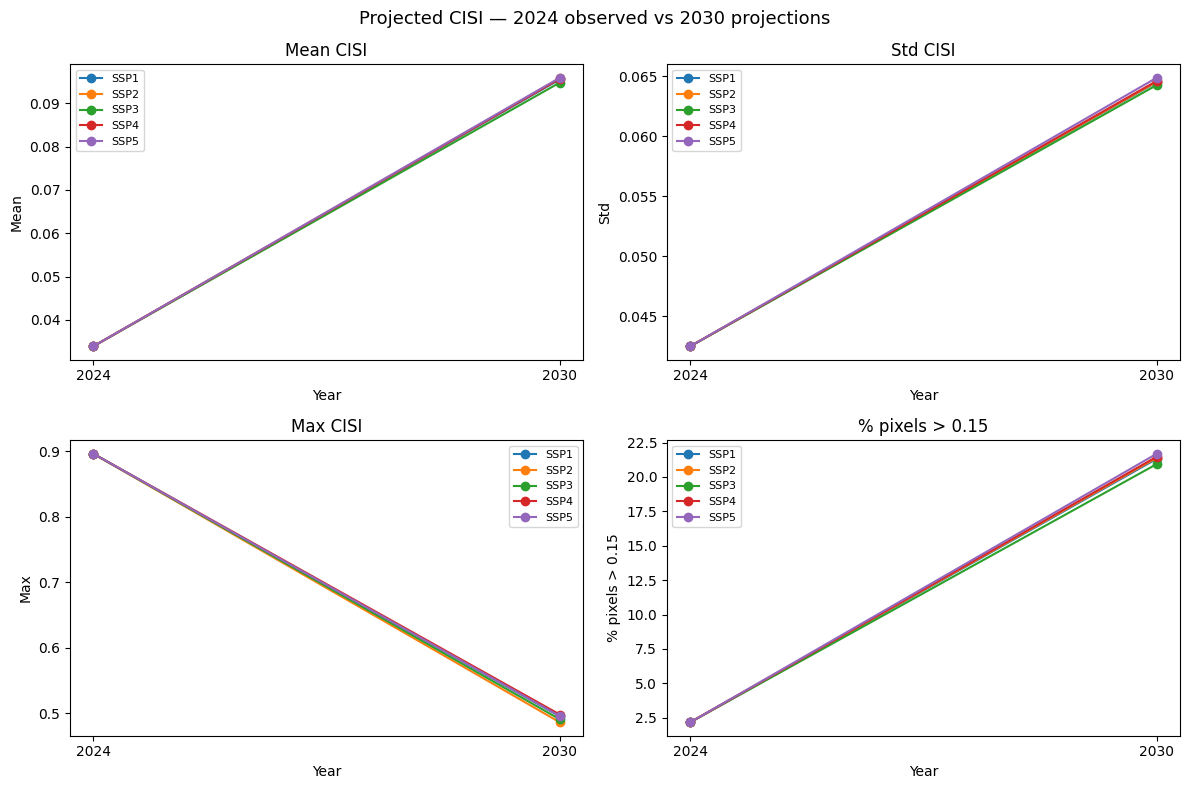

In [12]:
valid_2024 = cisi_2024[VALID_MASK & np.isfinite(cisi_2024)]
stats_2024 = {
    "mean": valid_2024.mean(),
    "std":  valid_2024.std(),
    "max":  valid_2024.max(),
    "high": (valid_2024 > 0.15).mean() * 100,
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Projected CISI — 2024 observed vs 2030 projections", fontsize=13)

for ax, key, title, ylabel in zip(axes.flat, keys, titles, ylabels):
    for ssp in SSPS:
        y_2024 = stats_2024[key]
        y_2030 = stats_proj[ssp][key][YEARS_ALL.index(2030)]
        ax.plot([2024, 2030], [y_2024, y_2030], marker="o", label=ssp)
    ax.set_title(title)
    ax.set_xlabel("Year")
    ax.set_ylabel(ylabel)
    ax.set_xticks([2024, 2030])
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('figures/stats_2024_2030.png', dpi=150, bbox_inches='tight')
plt.show()


## 13. Per-year overview — 2×3 grid (2024 actual + SSP1–5)

Saved figures/projection_overview_2030.png


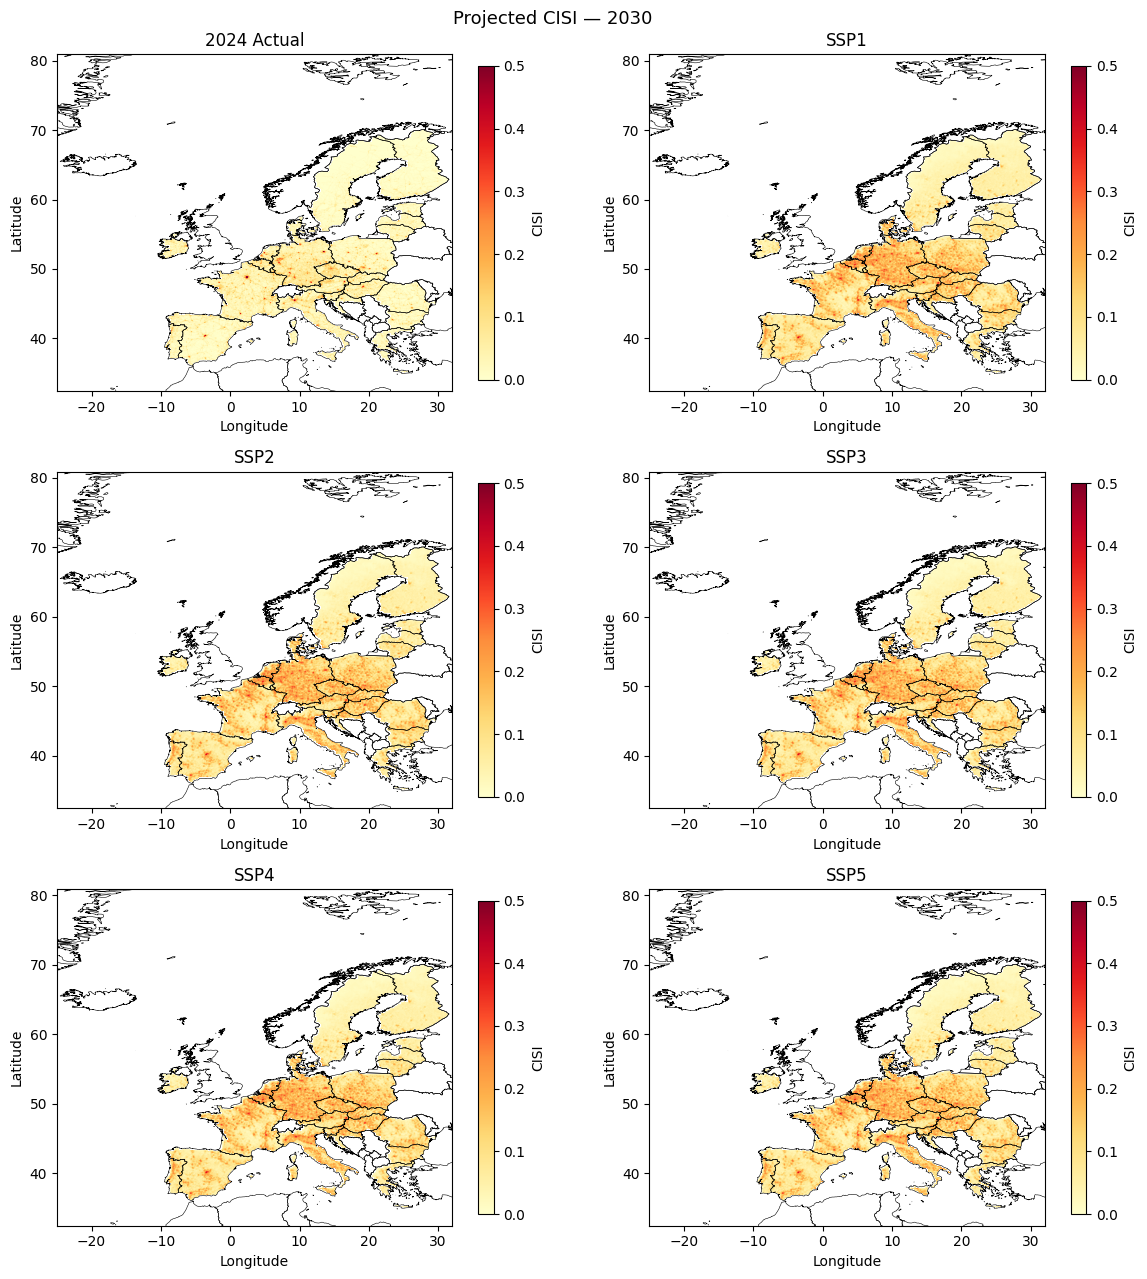

Saved figures/projection_overview_2050.png


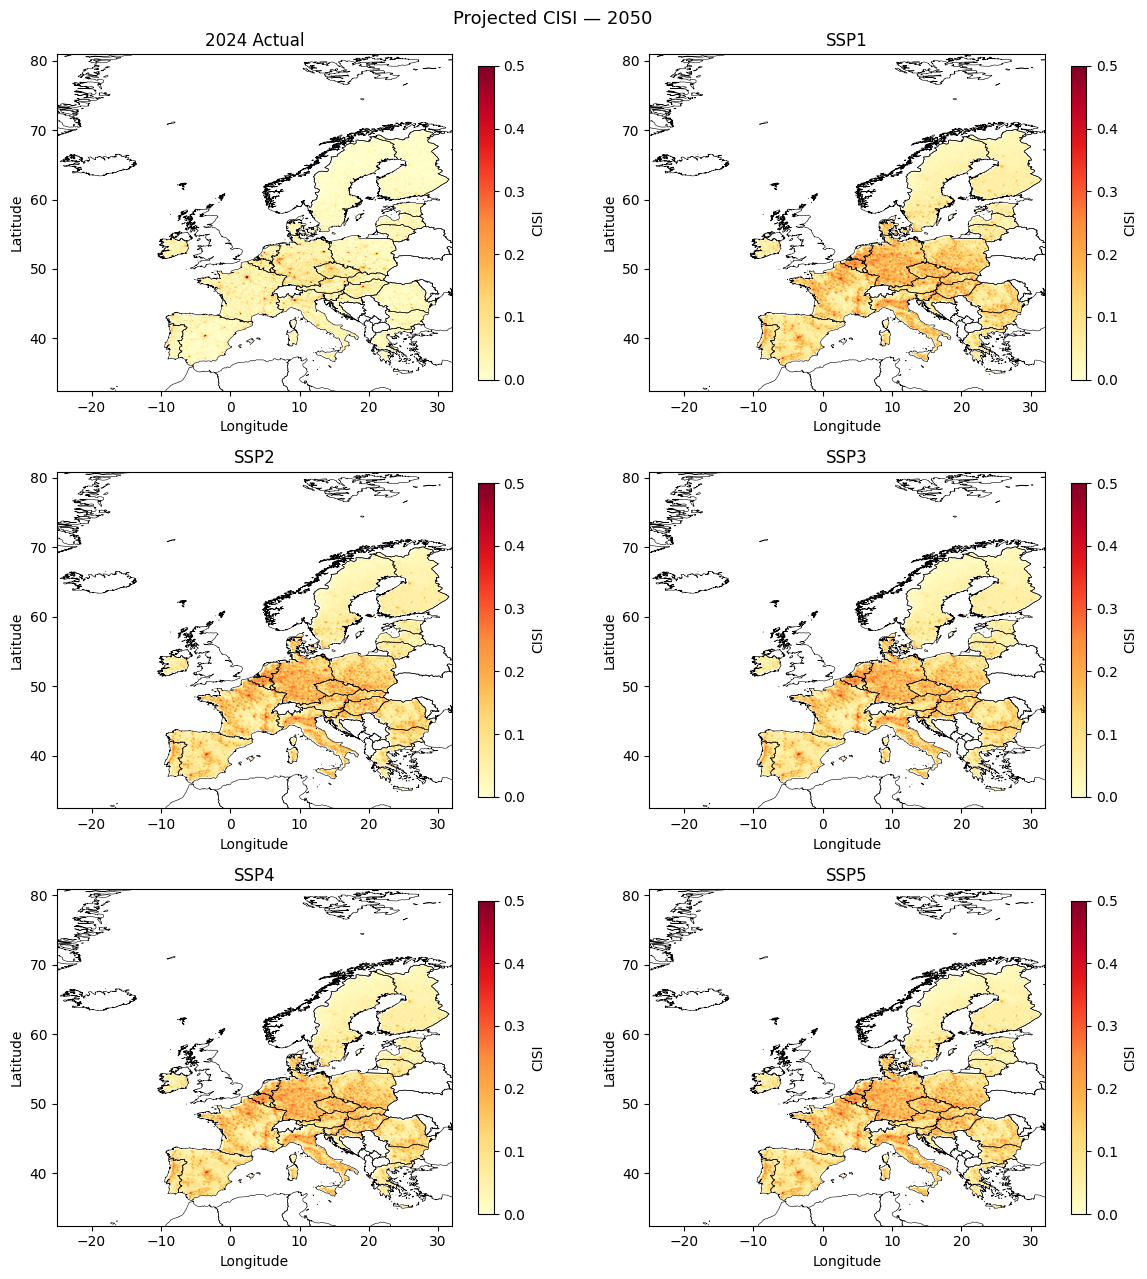

Saved figures/projection_overview_2100.png


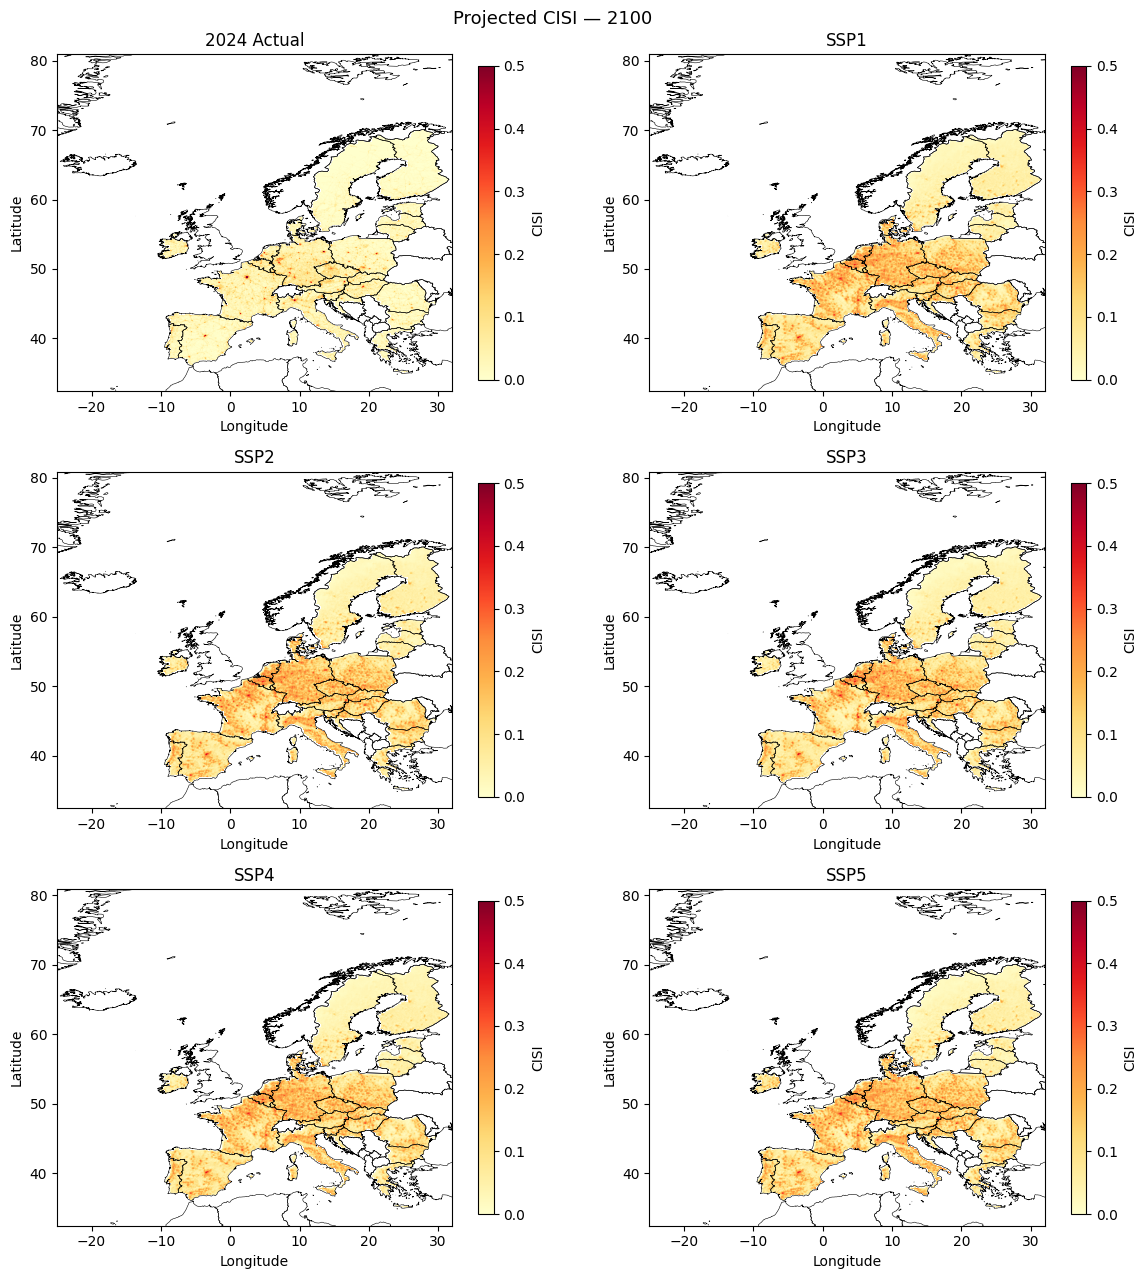

In [13]:
for year in YEARS:
    panels = [
        ("2024 Actual",  cisi_2024),
        ("SSP1",         predictions["SSP1"][year]),
        ("SSP2",         predictions["SSP2"][year]),
        ("SSP3",         predictions["SSP3"][year]),
        ("SSP4",         predictions["SSP4"][year]),
        ("SSP5",         predictions["SSP5"][year]),
    ]

    fig, axes = plt.subplots(3, 2, figsize=(12, 13))
    fig.suptitle(f"Projected CISI — {year}", fontsize=13)

    for ax, (title, data) in zip(axes.flat, panels):
        d = data.copy(); d[~VALID_MASK] = np.nan
        im = ax.imshow(d, cmap="YlOrRd", vmin=0, vmax=0.5,
                       extent=ext, origin="upper", aspect="auto")
        world.boundary.plot(ax=ax, linewidth=0.4, color="black")
        ax.set_xlim(REF_BOUNDS.left, REF_BOUNDS.right)
        ax.set_ylim(REF_BOUNDS.bottom, REF_BOUNDS.top)
        ax.set_title(title)
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        plt.colorbar(im, ax=ax, label="CISI", fraction=0.03)

    plt.tight_layout()
    out_fig = f"figures/projection_overview_{year}.png"
    plt.savefig(out_fig, dpi=150, bbox_inches='tight')
    print(f"Saved {out_fig}")
    plt.show()


Saved figures/distribution_overview_2030.png


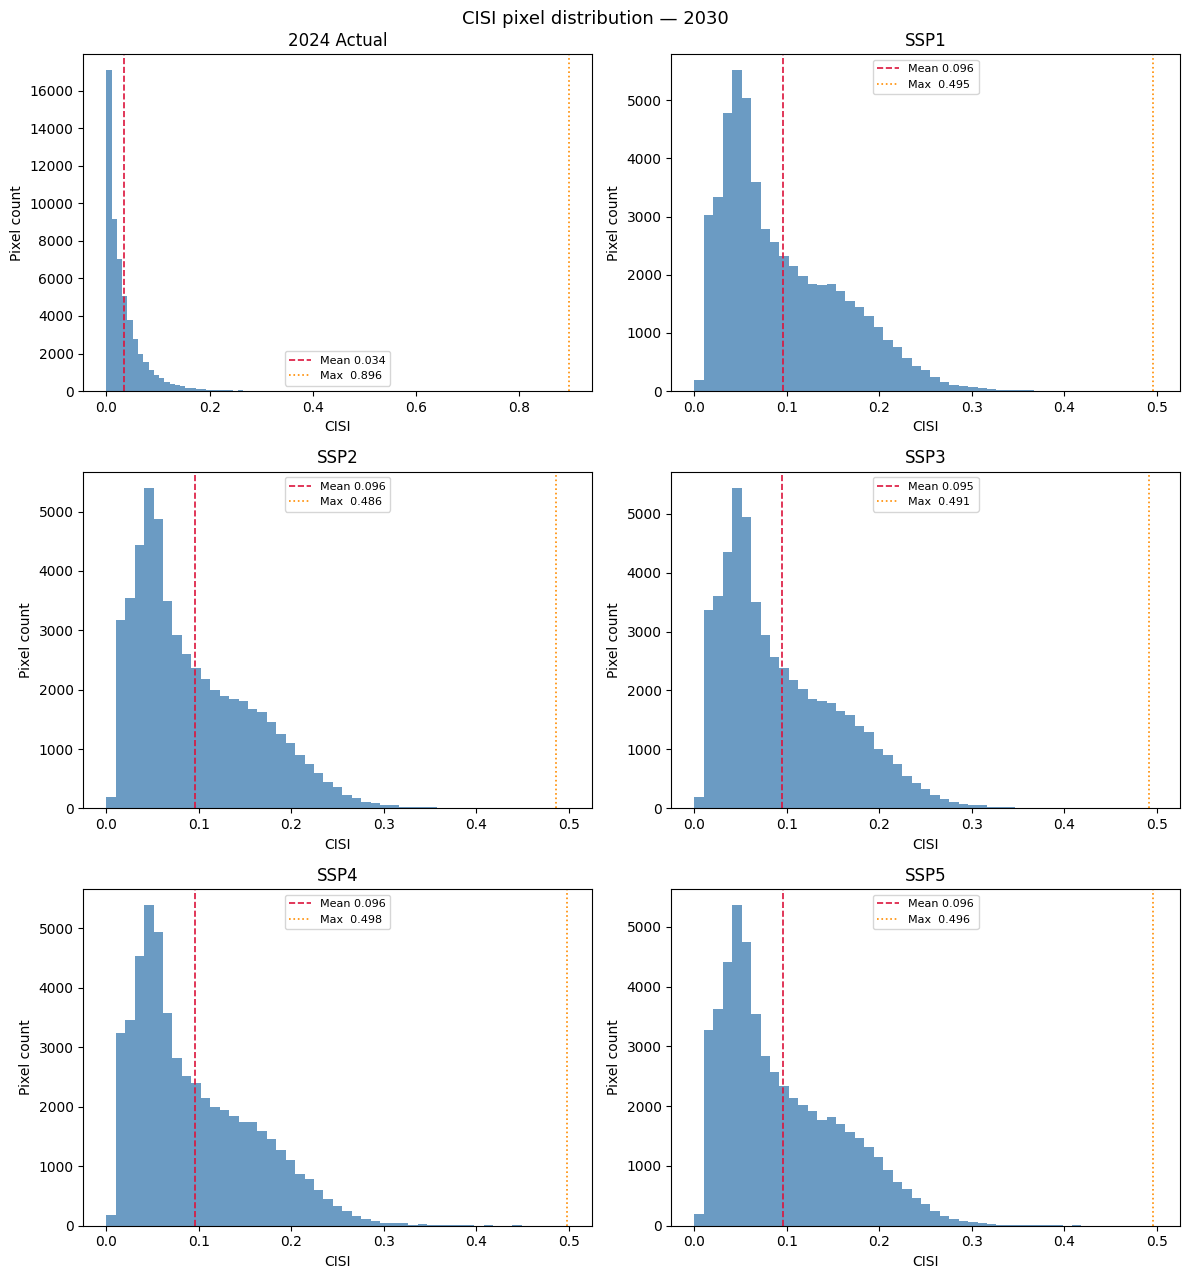

Saved figures/distribution_overview_2050.png


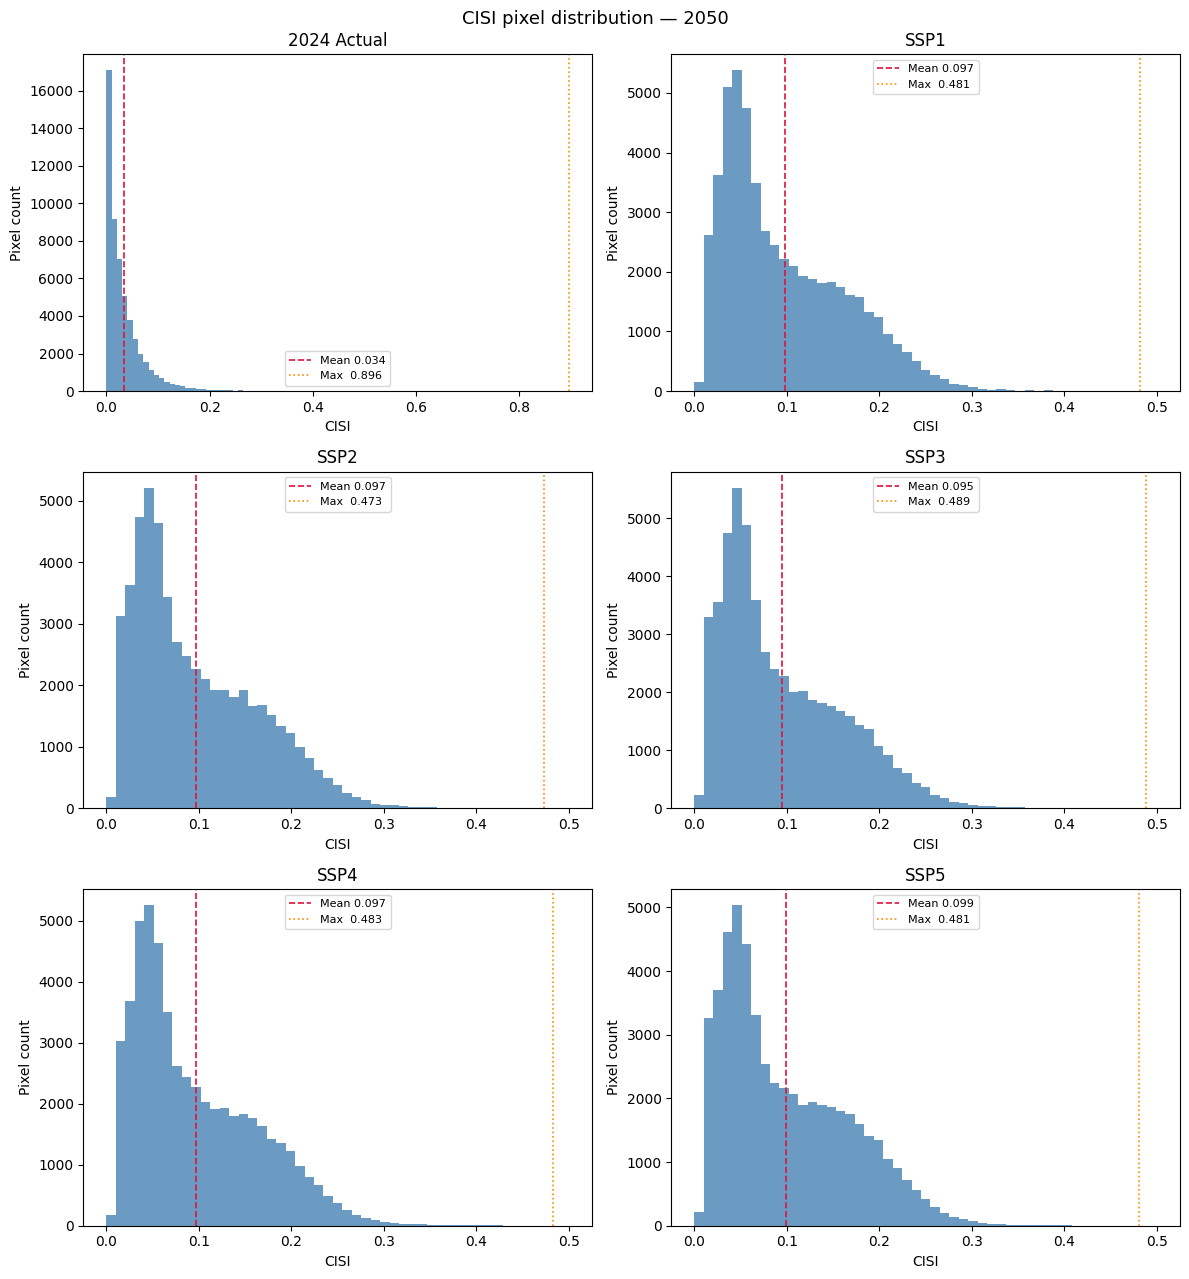

Saved figures/distribution_overview_2100.png


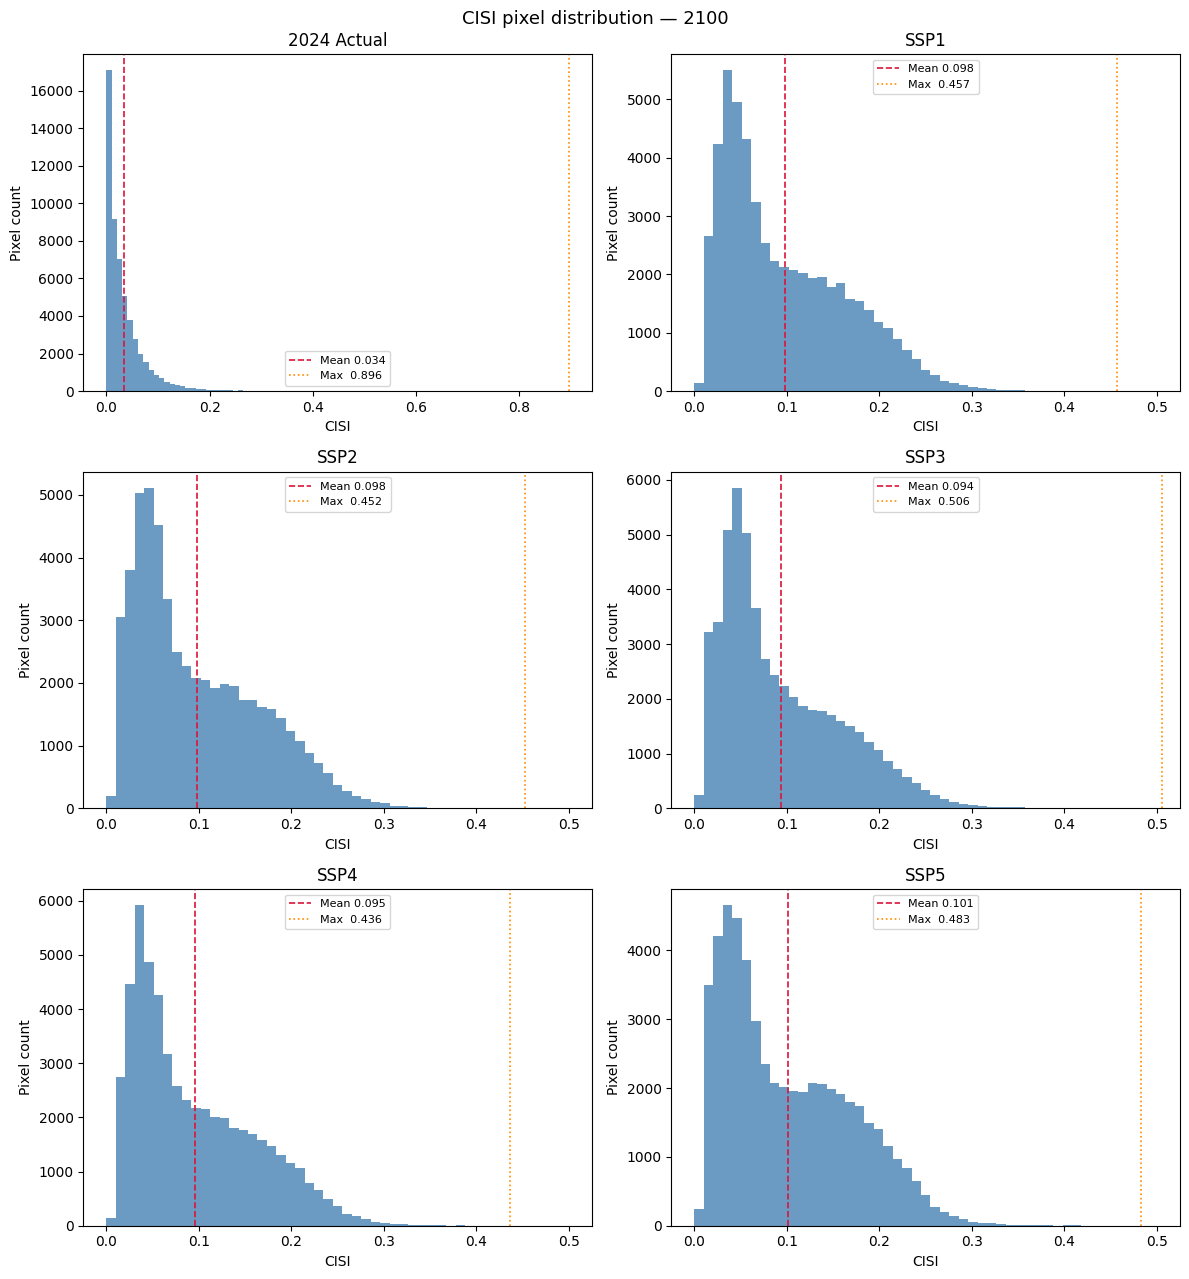

In [14]:
bins = np.linspace(0, 0.5, 50)

for year in YEARS:
    panels = [
        ("2024 Actual",  cisi_2024),
        ("SSP1",         predictions["SSP1"][year]),
        ("SSP2",         predictions["SSP2"][year]),
        ("SSP3",         predictions["SSP3"][year]),
        ("SSP4",         predictions["SSP4"][year]),
        ("SSP5",         predictions["SSP5"][year]),
    ]

    fig, axes = plt.subplots(3, 2, figsize=(12, 13))
    fig.suptitle(f"CISI pixel distribution — {year}", fontsize=13)

    for ax, (title, data) in zip(axes.flat, panels):
        d = data.copy(); d[~VALID_MASK] = np.nan
        vals = d[~np.isnan(d)]
        ax.hist(vals, bins=bins, color="steelblue", alpha=0.8)
        ax.axvline(vals.mean(), color="crimson",    linestyle="--", linewidth=1.2, label=f"Mean {vals.mean():.3f}")
        ax.axvline(vals.max(),  color="darkorange", linestyle=":",  linewidth=1.2, label=f"Max  {vals.max():.3f}")
        ax.set_title(title)
        ax.set_xlabel("CISI")
        ax.set_ylabel("Pixel count")
        ax.legend(fontsize=8)

    plt.tight_layout()
    out_fig = f"figures/distribution_overview_{year}.png"
    plt.savefig(out_fig, dpi=150, bbox_inches='tight')
    print(f"Saved {out_fig}")
    plt.show()
